# Nonlinear Dimensionality Reduction

PCA is a linear method, and it may not work well for nonlinear data. One popular nonlinear method is **t-distributed stochastic neighbor embedding (t-SNE)**.

Let $x_i$ be a data point in high dimensional space, and $y_i$ be its corresponding low dimensional (e.g. 2D) representation. We want to adjust the location of $y_i$ such that if $x_i$ and $x_j$ are close in high dimensional space, then $y_i$ and $y_j$ should also be close in low dimensional space.

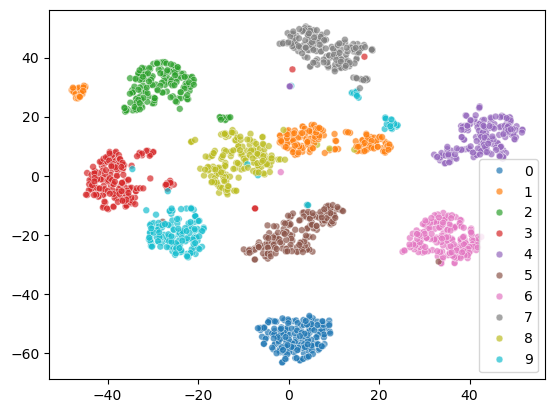

In [34]:

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

X,y = load_digits(return_X_y=True)

tsne = TSNE(n_components=2, random_state=0)

X_tsne = tsne.fit_transform(X)
sc = sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, legend='full', s=24, alpha=0.7, palette='tab10')

Text(0.5, 1.0, 'Digit 1 with Max X1')

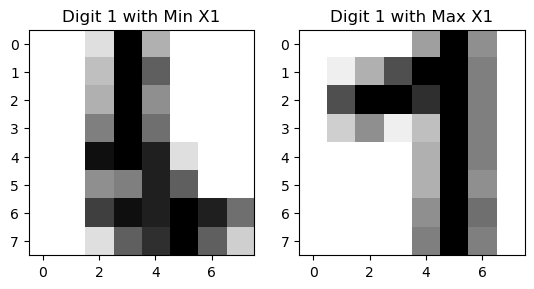

In [35]:
 
digit = 1
indices_of_digit = np.where(y == digit)[0]  # Get all indices where the digit is 3
X_tsne_digit = X_tsne[indices_of_digit]  # Filter t-SNE results for 3s

# Find the index of the minimum X1 value among all '1' digits
min_index = np.argmin(X_tsne_digit[:, 0])
actual_min_index = indices_of_digit[min_index]  # Get the actual index in the original dataset

max_index = np.argmax(X_tsne_digit[:, 0])
actual_max_index = indices_of_digit[max_index]

# Extract the corresponding image
image_of_digit_min = X[actual_min_index].reshape(8, 8)  # Reshape the flat vector back to 8x8
image_of_digit_max = X[actual_max_index].reshape(8, 8)



# Visualize the image
fig, axes = plt.subplots(1, 2)

axes[0].imshow(image_of_digit_min, cmap='binary')
axes[0].set_title('Digit 1 with Min X1')

axes[1].imshow(image_of_digit_max, cmap='binary')
axes[1].set_title('Digit 1 with Max X1')

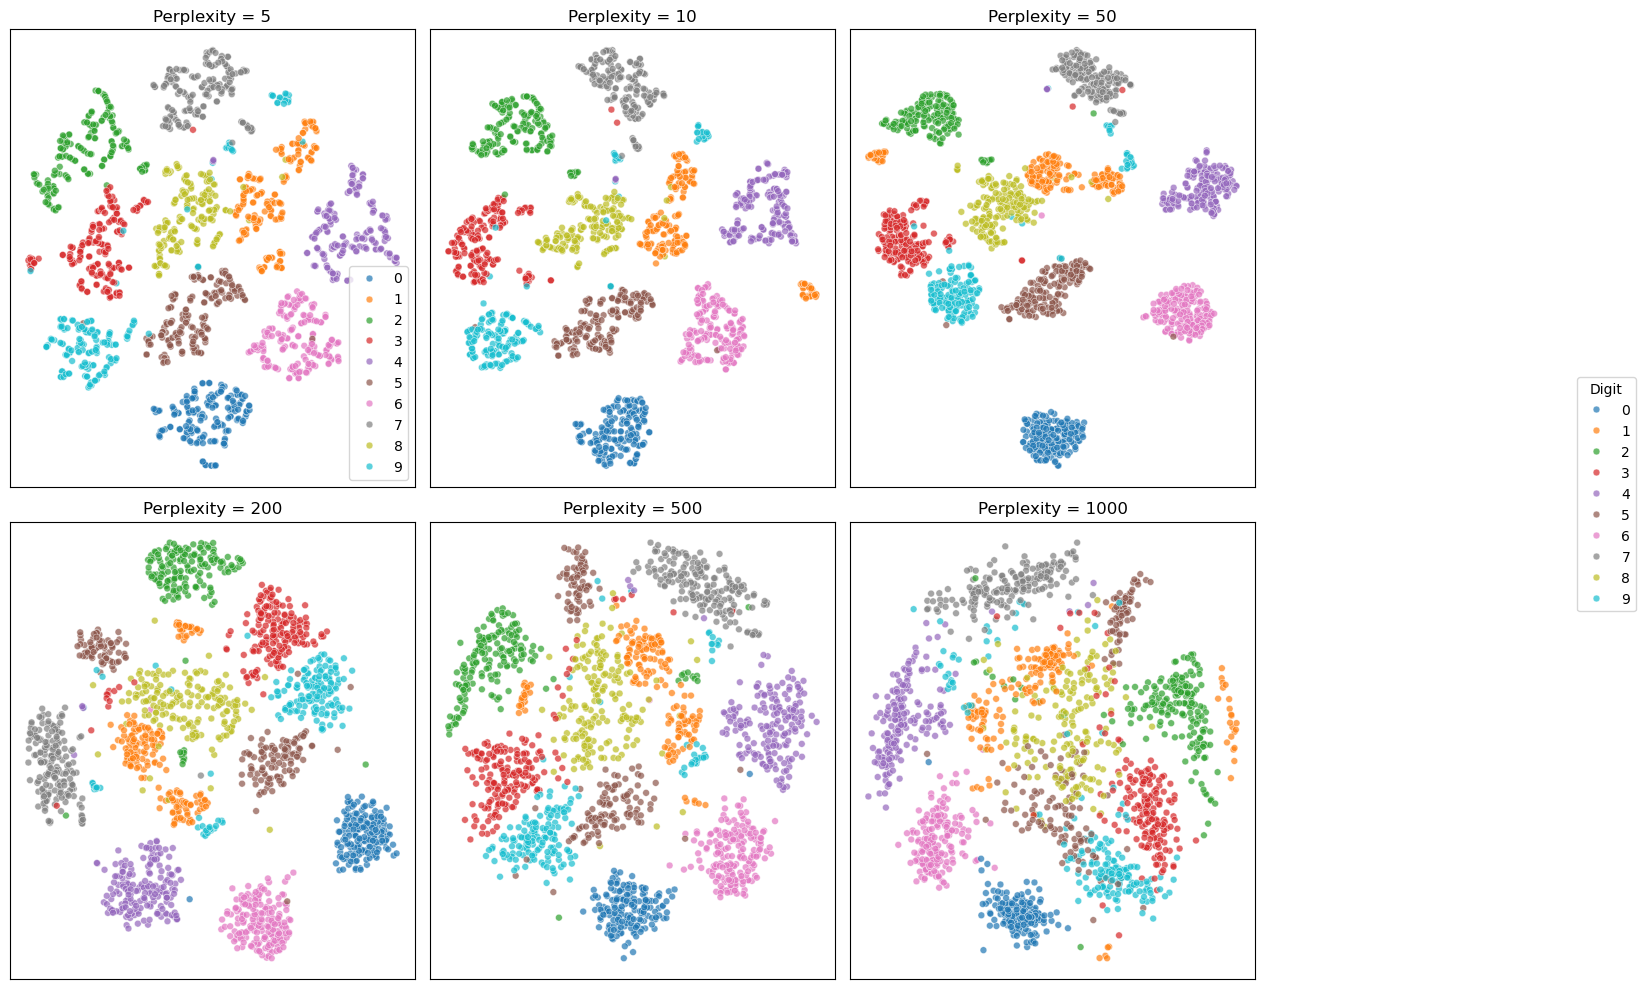

In [ ]:
# Show t-SNE results for different perplexities, with only one legend on the right

import numpy as np

perplexities = [3, 10, 50, 200, 500, 1000]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (ax, perp) in enumerate(zip(axes.flat, perplexities)):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X)
    sc = sns.scatterplot(
        x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y , s=24, alpha=0.7, palette='tab10', ax=ax
    )
    ax.set_title(f"Perplexity = {perp}")
    ax.set_xticks([])
    ax.set_yticks([])

# Only show the legend for the first subplot, and move it to the right of the figure
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Digit", bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [9]:
import scanpy as sc

# Load example single-cell data
adata = sc.datasets.pbmc3k()  # PBMC 3k dataset (real RNA-seq data)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=1000, subset=True)
sc.pp.scale(adata)

# PCA + t-SNE
sc.tl.pca(adata, svd_solver='arpack')
sc.tl.tsne(adata, perplexity=30)  # You can try different values

# Plot
sc.pl.tsne(adata, color=['CST3', 'NKG7', 'PPBP'], size=10, title='t-SNE on PBMC 3k')

KeyError: 'Could not find key CST3 in .var_names or .obs.columns.'

<Figure size 2183.4x480 with 0 Axes>

In [23]:
pca.components_

array([[-6.13623257e-02, -1.95302071e-03,  9.98113646e-01],
       [ 9.98115359e-01, -7.49312547e-04,  6.13609648e-02]])

[[-0.06135036 -0.00949673  0.99807111]
 [ 0.99807487 -0.00969322  0.06125836]]
S-curve, t-SNE perplexity=5 in 0.78 sec
S-curve, t-SNE perplexity=30 in 0.87 sec
S-curve, t-SNE perplexity=50 in 0.91 sec
S-curve, t-SNE perplexity=100 in 1.2 sec
S-curve, t-SNE perplexity=900 in 2.5 sec


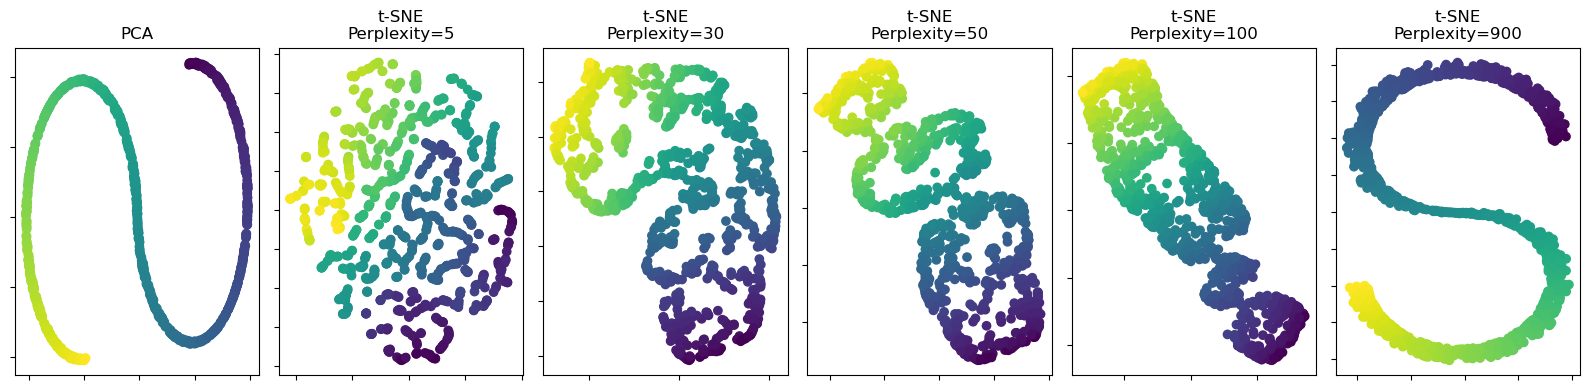

In [26]:
# Compare PCA and t-SNE on the S-curve dataset with varying perplexity

from time import time
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter
from sklearn import datasets, manifold, decomposition


n_components = 2
perplexities = [5, 30, 50, 100, 900]

# Generate S-curve data
n_samples = 1000
X, color = datasets.make_s_curve(n_samples, random_state=0)



fig, axes = plt.subplots(1, 1 + len(perplexities), figsize=(16, 4))

# PCA
pca = decomposition.PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(pca.components_)
ax = axes[0]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=color)
ax.set_title("PCA")
ax.xaxis.set_major_formatter(NullFormatter())
ax.yaxis.set_major_formatter(NullFormatter())

# t-SNE with different perplexities
for i, perplexity in enumerate(perplexities):
    ax = axes[i + 1]
    t0 = time()
    tsne = manifold.TSNE(
        n_components=n_components,
        init="random",
        random_state=0,
        perplexity=perplexity,
        learning_rate="auto",
        max_iter=300,
    )
    X_tsne = tsne.fit_transform(X)
    t1 = time()
    print(f"S-curve, t-SNE perplexity={perplexity} in {t1 - t0:.2g} sec")
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color)
    ax.set_title(f"t-SNE\nPerplexity={perplexity}")
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())

plt.tight_layout()
plt.show()

In [21]:
import plotly.graph_objs as go
from sklearn import datasets



fig = go.Figure(data=[go.Scatter3d(
    x=X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    mode='markers',
    marker=dict(
        size=3,
        color=color,
        colorscale='Viridis',
        opacity=0.8
    )
)])

fig.update_layout(
    title="Interactive 3D S-curve",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    )
)

fig.show()